<a href="https://colab.research.google.com/github/HurtovaAlina/ITStep-AI/blob/superwised_learning/practice_histograms_boxes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [296]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/Used%20Car%20Dataset.csv", index_col="Unnamed: 0")
#df.drop(columns=['car_name', 'registration_year', 'ownsership', 'transmission'], inplace=True)

Дані про ціни вживаних автомобілів у Індії
* car_name - назва авто у форматі 'рік компанія основна назва'
* registration_year - місяць та рік реєстрації
* ownsership - кількість власників у форматі 'Second owner'
* transmission - тип коробки передач
* insurance_validity - тип страховки
* fuel_type - вид палива
* seats - кількість сидінь
* kms_driven - пробіг
* manufacturing_year - рік виробництва, має тип object, потрібно застосувати astype(int)
* mileage(kmpl) - скільки кілометрів проїде за літр палива
* engine(cc) - об'єм двигуна у мл
* max_power(bhp) - потужність у кінських силах
* torque(Nm) - крутний момент двигуна
* price(in lakhs) - ціна у сто тисяч рупій

[Повний аналіз даних](https://www.kaggle.com/code/abdelrasoul/used-cars-prices-prediction)

In [297]:
df.head()

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99
2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0,23.75
3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0,13.56
4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0,24.00


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [298]:
df.shape

(1553, 14)

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1553 entries, 0 to 1552
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   car_name            1553 non-null   object 
 1   registration_year   1553 non-null   object 
 2   insurance_validity  1553 non-null   object 
 3   fuel_type           1553 non-null   object 
 4   seats               1553 non-null   int64  
 5   kms_driven          1553 non-null   int64  
 6   ownsership          1553 non-null   object 
 7   transmission        1553 non-null   object 
 8   manufacturing_year  1553 non-null   object 
 9   mileage(kmpl)       1550 non-null   float64
 10  engine(cc)          1550 non-null   float64
 11  max_power(bhp)      1550 non-null   float64
 12  torque(Nm)          1549 non-null   float64
 13  price(in lakhs)     1553 non-null   float64
dtypes: float64(5), int64(2), object(7)
memory usage: 182.0+ KB


In [300]:
df.isna().sum()

,0
car_name,0
registration_year,0
insurance_validity,0
fuel_type,0
seats,0
kms_driven,0
ownsership,0
transmission,0
manufacturing_year,0
mileage(kmpl),3


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

In [301]:
df.describe()

,seats,kms_driven,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
count,1553.000000,1553.000000,1550.000000,1.550000e+03,1.550000e+03,1.549000e+03,1553.000000
mean,91.480361,52841.931101,236.927277,1.471857e+10,1.471857e+10,1.423989e+04,166.141494
std,2403.424060,40067.800347,585.964295,2.185629e+11,2.185629e+11,9.666241e+04,3478.855090
min,4.000000,620.000000,7.810000,5.000000e+00,5.000000e+00,5.000000e+00,1.000000
25%,5.000000,30000.000000,16.342500,1.197000e+03,1.197000e+03,4.000000e+02,4.660000
50%,5.000000,49134.000000,18.900000,1.462000e+03,1.462000e+03,1.173000e+03,7.140000
75%,5.000000,70000.000000,22.000000,1.995000e+03,1.995000e+03,8.850000e+03,17.000000
max,67000.000000,810000.000000,3996.000000,3.258640e+12,3.258640e+12,1.464800e+06,95000.000000


In [302]:
df.dtypes

,0
car_name,object
registration_year,object
insurance_validity,object
fuel_type,object
seats,int64
kms_driven,int64
ownsership,object
transmission,object
manufacturing_year,object
mileage(kmpl),float64


Text(0.5, 0, 'amount')

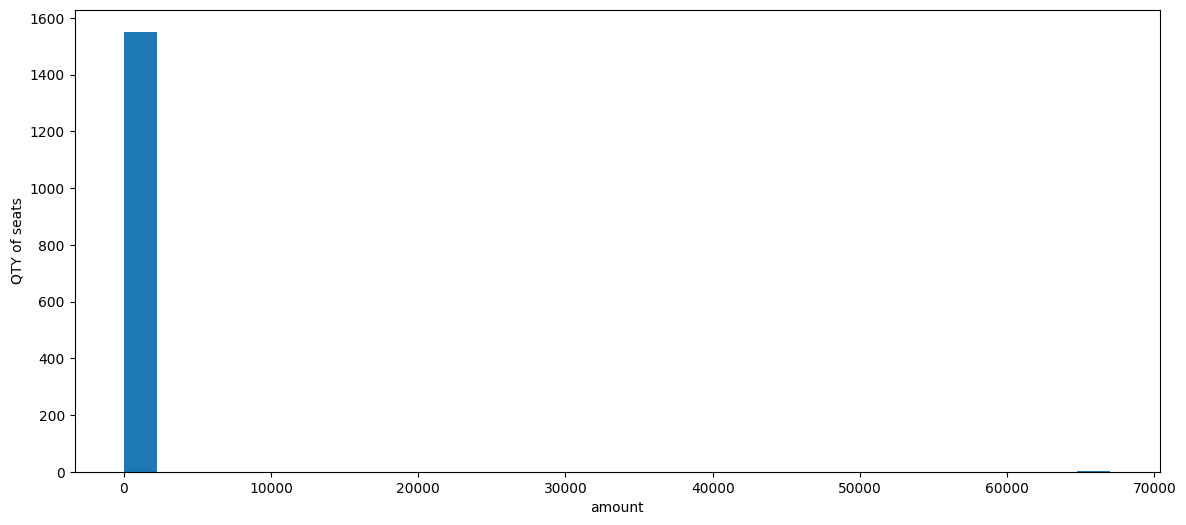

In [303]:
ax = df['seats'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('QTY of seats')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

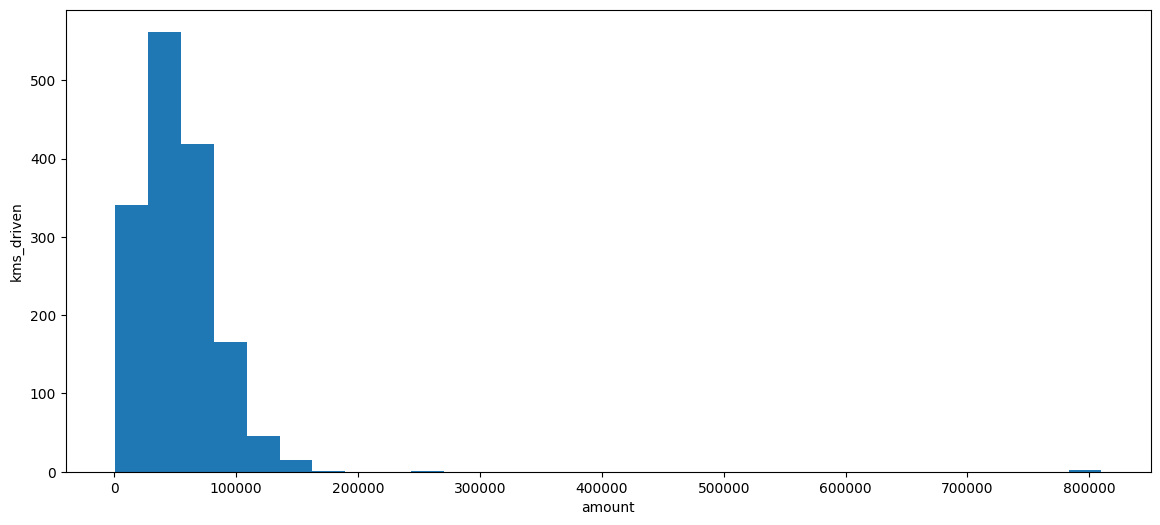

In [304]:
ax = df['kms_driven'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('kms_driven')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

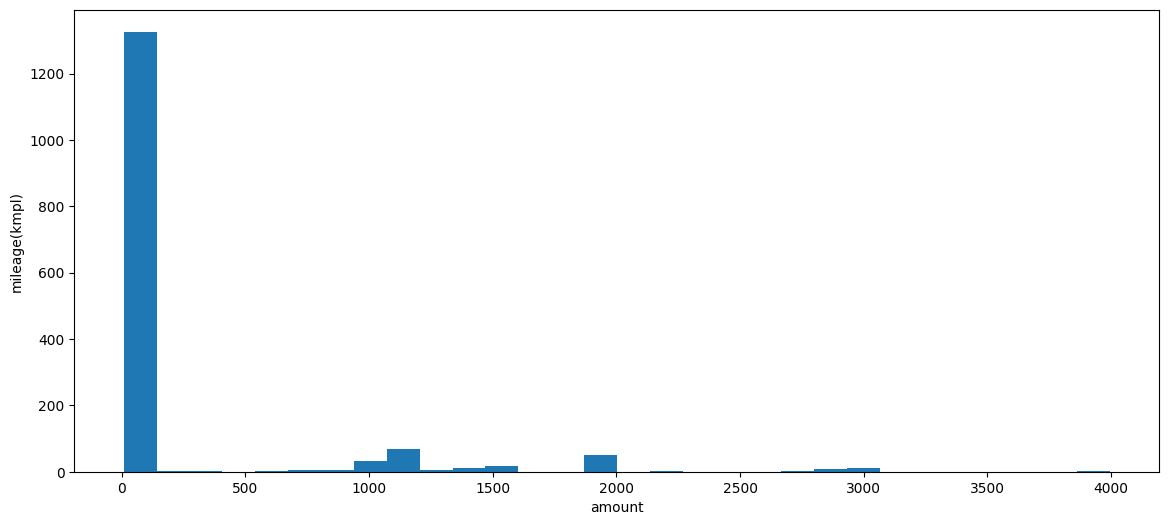

In [305]:
ax = df['mileage(kmpl)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('mileage(kmpl)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

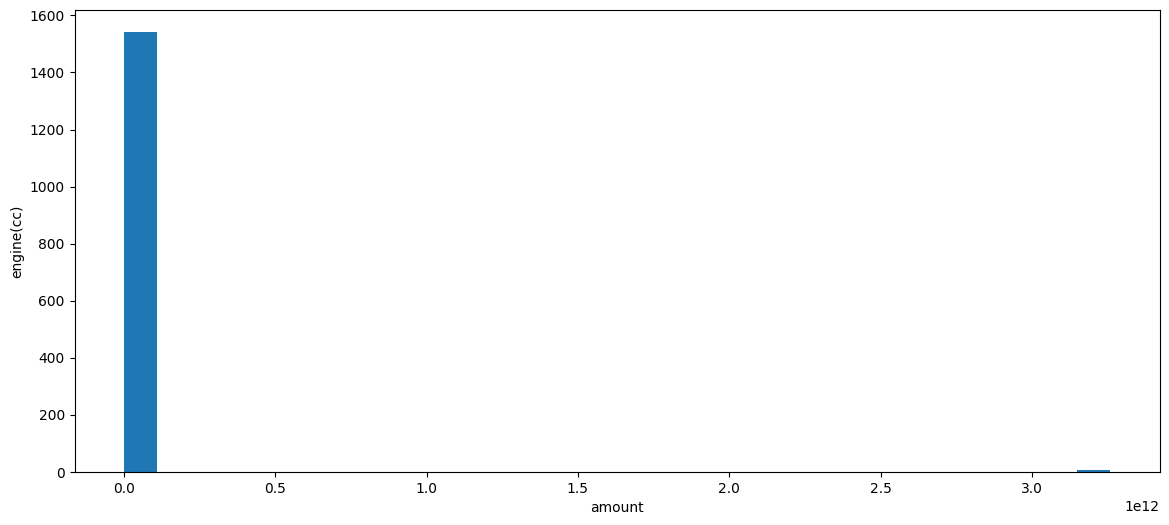

In [306]:
ax = df['engine(cc)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('engine(cc)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

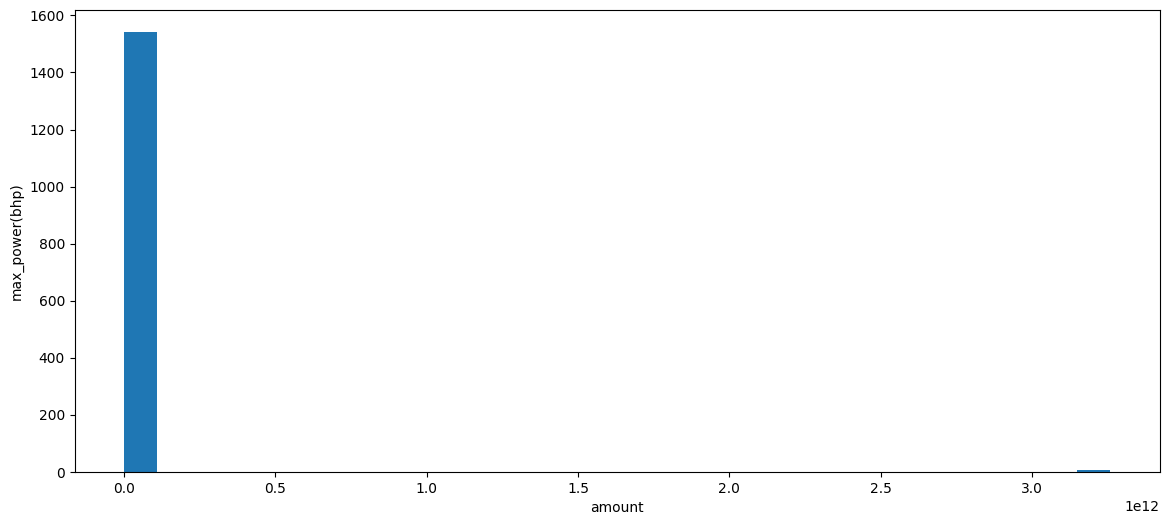

In [307]:
ax = df['max_power(bhp)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('max_power(bhp)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

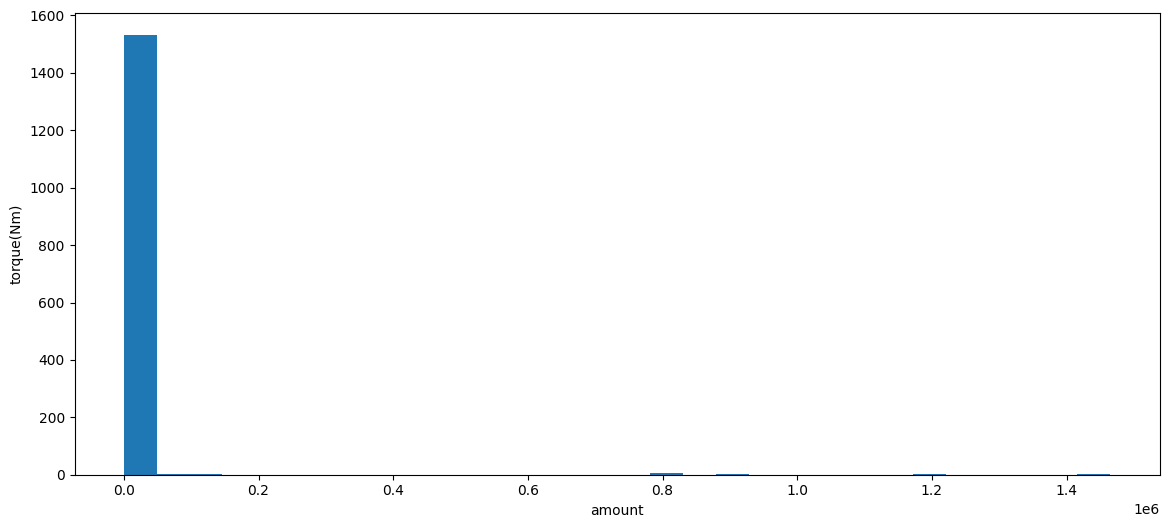

In [308]:
ax = df['torque(Nm)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('torque(Nm)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

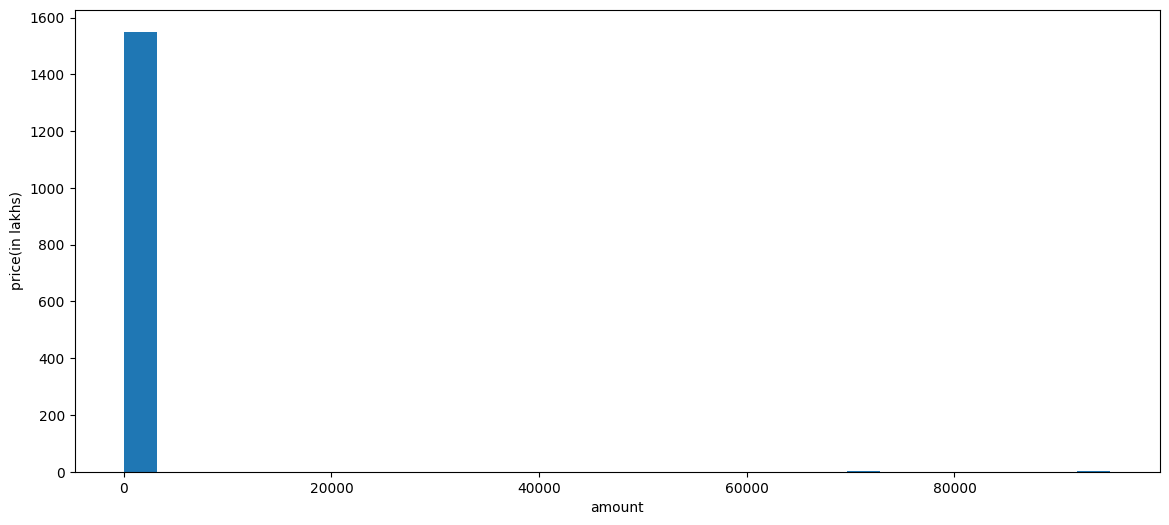

In [309]:
ax = df['price(in lakhs)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('price(in lakhs)')
ax.set_xlabel('amount')

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

In [310]:
df.dtypes

,0
car_name,object
registration_year,object
insurance_validity,object
fuel_type,object
seats,int64
kms_driven,int64
ownsership,object
transmission,object
manufacturing_year,object
mileage(kmpl),float64


In [311]:
mask= df['seats']<10
mask.sum()

np.int64(1551)

In [312]:
df = df[mask]

<Axes: >

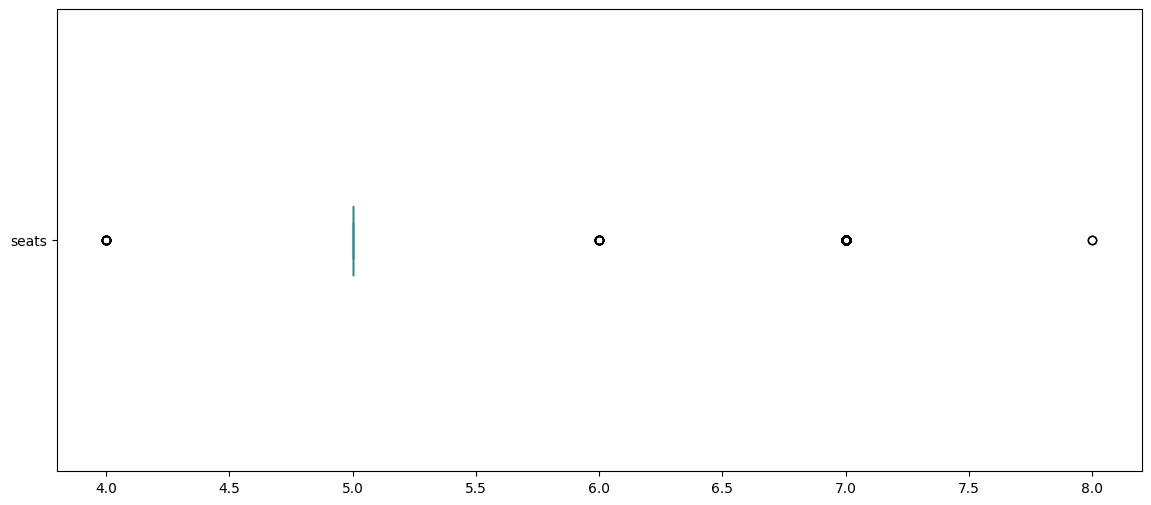

In [313]:
df['seats'].plot(kind='box', vert=False, figsize=(14,6))

In [315]:
mask= df['kms_driven']<175000
mask.sum()

np.int64(1547)

In [316]:
df = df[mask]

<Axes: >

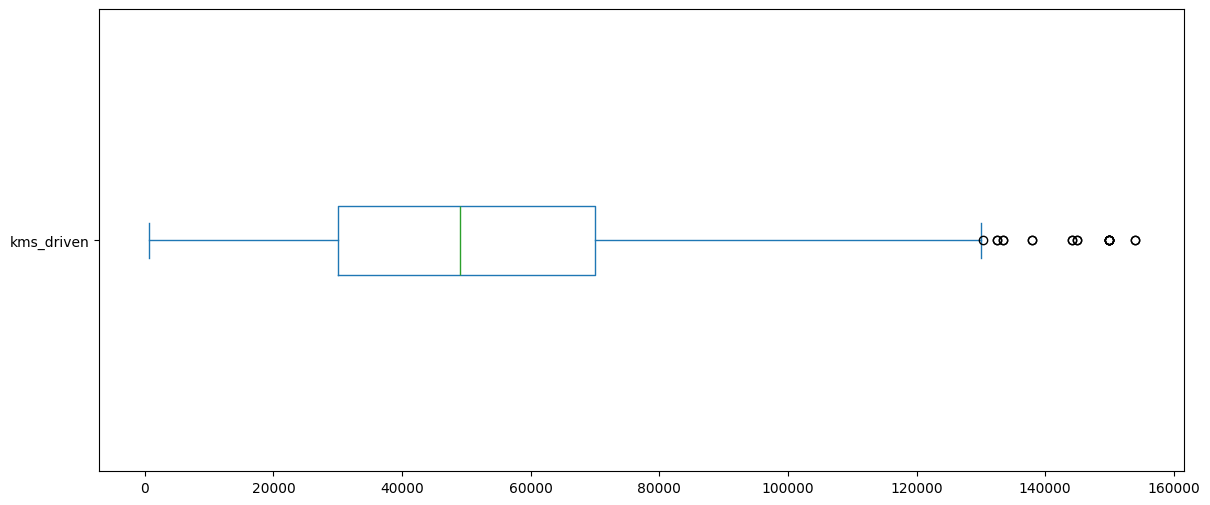

In [317]:
df['kms_driven'].plot(kind='box', vert=False, figsize=(14,6))

In [319]:
mask= df['mileage(kmpl)']<100
mask.sum()

np.int64(1322)

In [320]:
df = df[mask]

<Axes: >

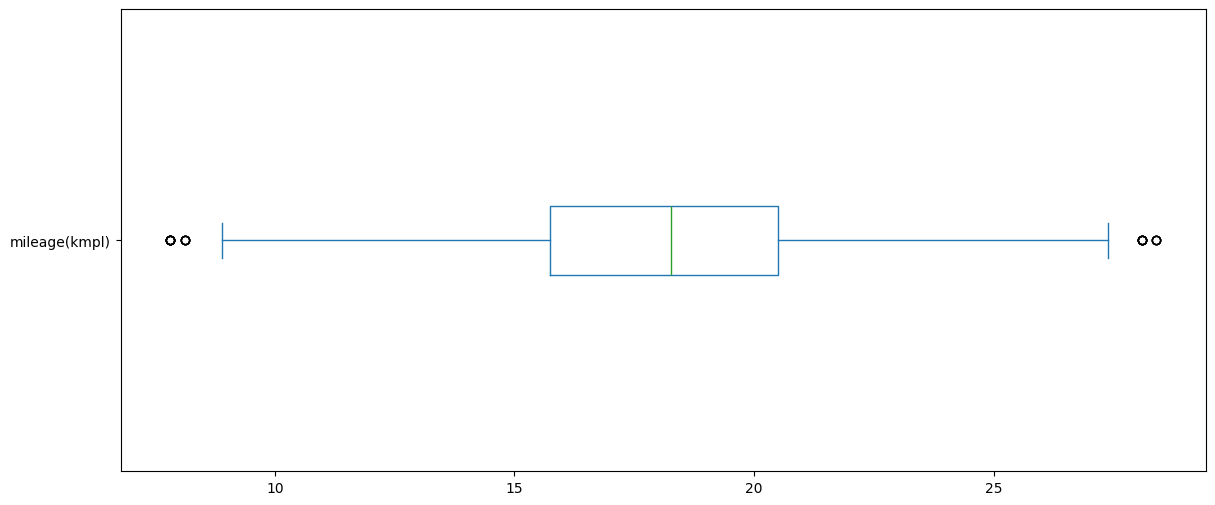

In [321]:
df['mileage(kmpl)'].plot(kind='box', vert=False, figsize=(14,6))

In [322]:
mask= df['engine(cc)']<10000
mask.sum()

np.int64(1322)

In [323]:
df = df[mask]

<Axes: >

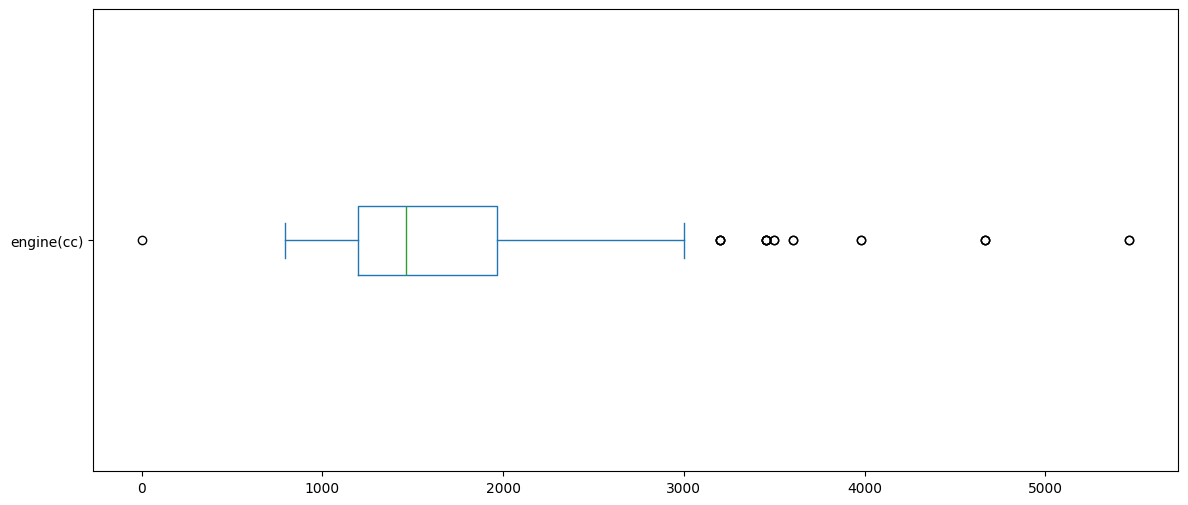

In [324]:
df['engine(cc)'].plot(kind='box', vert=False, figsize=(14,6))

In [325]:
mask= df['max_power(bhp)']<10000
mask.sum()

np.int64(1322)

In [326]:
df = df[mask]

<Axes: >

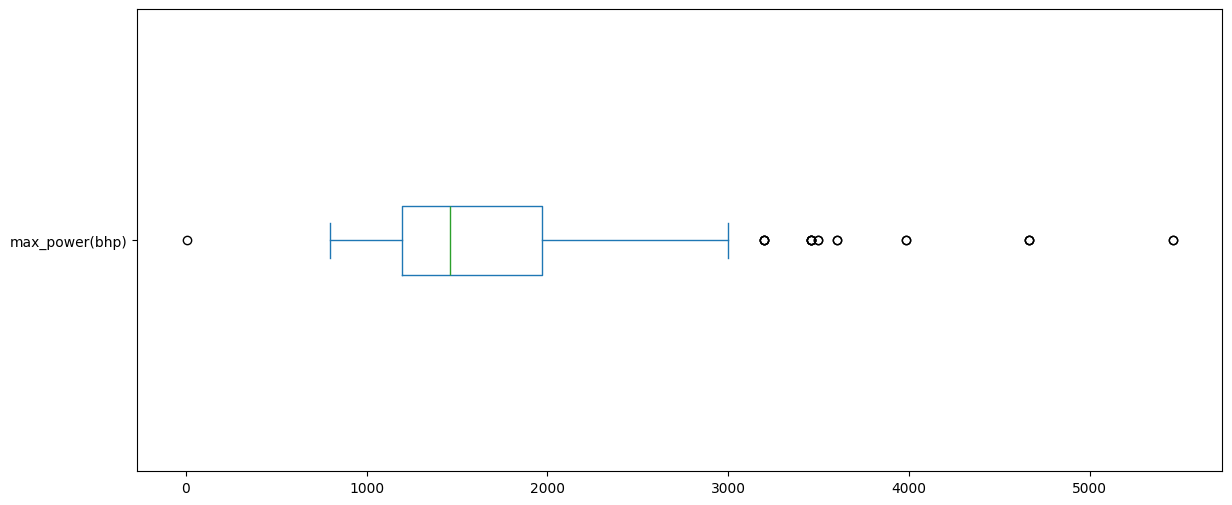

In [327]:
df['max_power(bhp)'].plot(kind='box', vert=False, figsize=(14,6))

In [328]:
mask= df['torque(Nm)']<300
mask.sum()

np.int64(231)

In [329]:
df = df[mask]

<Axes: >

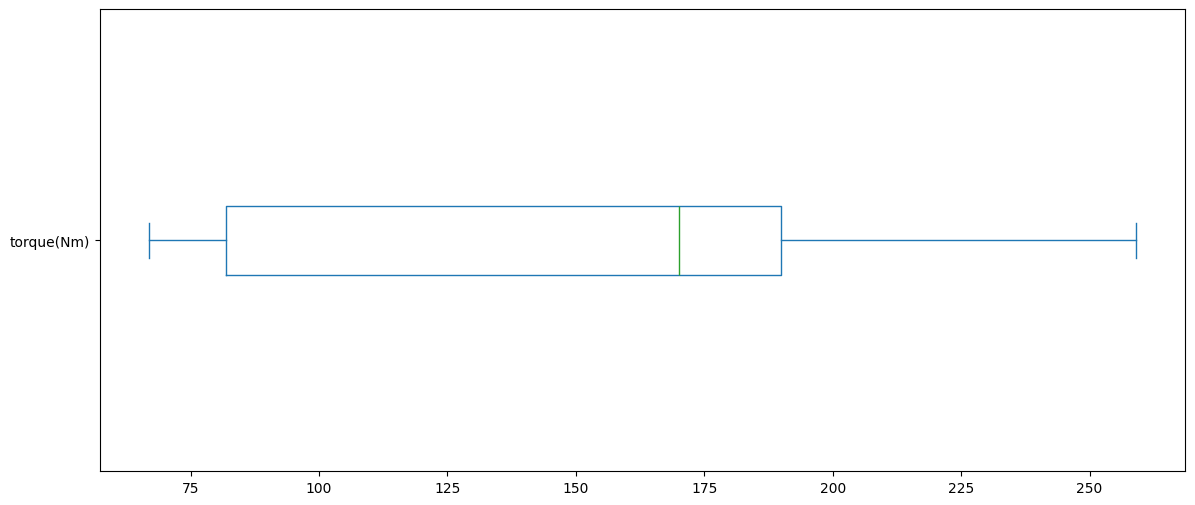

In [330]:
df['torque(Nm)'].plot(kind='box', vert=False, figsize=(14,6))

In [331]:
mask= df['price(in lakhs)']<25
mask.sum()

np.int64(157)

In [332]:
df = df[mask]

<Axes: >

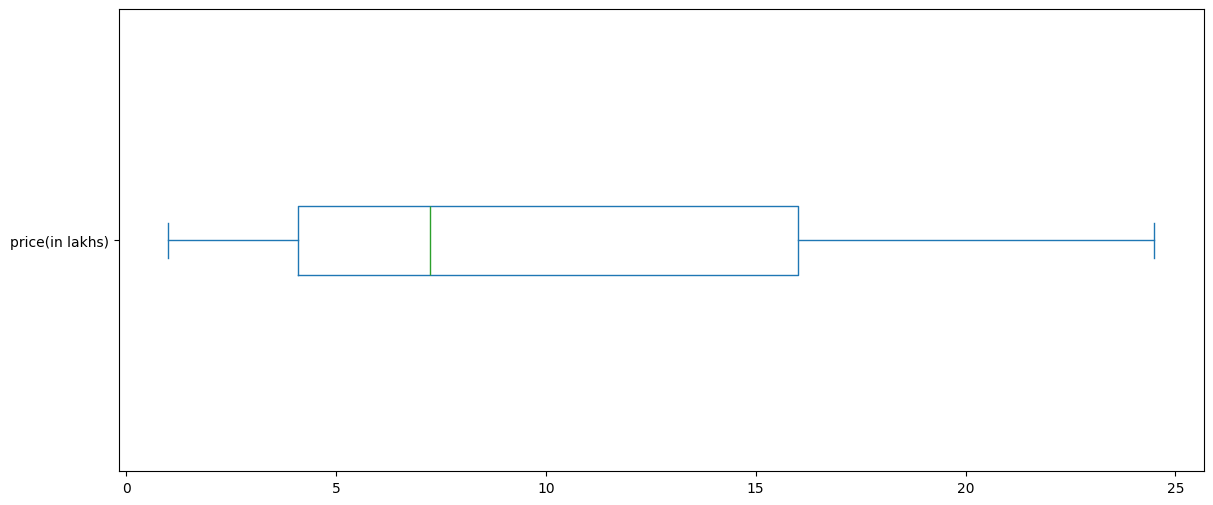

In [333]:
df['price(in lakhs)'].plot(kind='box', vert=False, figsize=(14,6))

# Завдання 4
Створіть Pipeline для обробки даних